### Nguyễn Thành Lộc
### 2350160016
### Buổi 3

# Sáng Thực Hành

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split, TensorDataset
from torch.optim.lr_scheduler import StepLR, MultiStepLR, ExponentialLR, CosineAnnealingLR, ReduceLROnPlateau
from torch.nn.utils import clip_grad_norm_, clip_grad_value_
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import math


## Setup Infrastructure(Thiết lập hạ tầng)

In [ ]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
# Create output directory for plots, models, and logs
output_dir = "04_training_neural_networks_outputs"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(os.path.join(output_dir, "runs"), exist_ok=True)
os.makedirs(os.path.join(output_dir, "saved_models"), exist_ok=True)

1. Giới thiệu về huấn luyện mạng nơ-ron

2. Chuẩn bị dữ liệu cho Dataset và DataLoader

In [ ]:
class MyCustomDataset(Dataset):
  """Example of a custom Dataset."""
  def __init__(self, num_samples=1000, input_features=10, num_classes=2, transform=None):
    # Generate some random data for demonstration
    self.data = torch.randn(num_samples, input_features)
    self.targets = torch.randint(0, num_classes, (num_samples,))
    self.transform = transform
    print(f"CustomDataset: Created {num_samples} samples.")
  def __len__(self):
      return len(self.data)
  def __getitem__(self, idx):
    sample = self.data[idx]
    target = self.targets[idx]
    if self.transform:
      sample = self.transform(sample)
    return sample, torch.tensor(target, dtype=torch.long)
# Using the custom dataset
print ("--- Custom Dataset Example ---")
custom_train_dataset = MyCustomDataset(num_samples=100, input_features=5,num_classes=3)
sample_data, sample_target = custom_train_dataset[0]
print(f"First sample data shape: {sample_data.shape}, target: {sample_target}")
# Using DataLoader with the custom dataset
custom_train_loader = DataLoader(custom_train_dataset, batch_size=32,shuffle=True)
print(f"Number of batches in custom_train_loader: {len(custom_train_loader)}")
for i, (batch_data, batch_targets) in enumerate(custom_train_loader):
 print(f"Batch {i+1} data shape: {batch_data.shape}, targets shape:{batch_targets.shape}")
 if i == 0: # Print only first batch details
    break


In [ ]:
 # Using torchvision for a standard dataset (MNIST)
print("\n--- torchvision MNIST Dataset and DataLoader Example ---")
mnist_transform = transforms.Compose([
transforms.ToTensor(),
transforms.Normalize((0.1307,), (0.3081,)) # MNIST mean and std
])
mnist_train_dataset = torchvision.datasets.MNIST(
root='./data', train=True, download=True, transform=mnist_transform
)
mnist_train_loader = DataLoader(mnist_train_dataset, batch_size=64,shuffle=True)
print(f"Number of samples in MNIST training set: {len(mnist_train_dataset)}")
print(f"Number of batches in MNIST train_loader: {len(mnist_train_loader)}")
mnist_batch_data, mnist_batch_targets = next(iter(mnist_train_loader))
print(f"MNIST first batch data shape: {mnist_batch_data.shape}, targets shape:{mnist_batch_targets.shape}")
print("`Dataset` manages data samples, `DataLoader` provides batches for training.")


3.Định nghĩa mạng rơ-ron



In [ ]:
#cell 1
class SimpleNN(nn.Module):
  def __init__(self, input_size=28*28, hidden_size=128, num_classes=10,use_dropout=False, use_bn=False):
    super(SimpleNN, self).__init__()
    self.use_dropout = use_dropout
    self.use_bn = use_bn
    self.fc1 = nn.Linear(input_size, hidden_size)
    if self.use_bn:
      self.bn1 = nn.BatchNorm1d(hidden_size)
    self.relu = nn.ReLU()
    if self.use_dropout:
      self.dropout = nn.Dropout(0.5)
    self.fc2 = nn.Linear(hidden_size, num_classes)

  def forward(self, x):
    x = x.view(x.size(0), -1) # Flatten the input
    x = self.fc1(x)
    if self.use_bn:
      x = self.bn1(x)
    x = self.relu(x)
    if self.use_dropout:
      x = self.dropout(x)
    x = self.fc2(x)
    return x

#cell 2
# Create a model instance
model = SimpleNN().to(device)
print("Neural Network Architecture:")
print(model)

1.4 Vòng lặp huấn luyện

In [ ]:
# Dummy data for demonstration
dummy_inputs = torch.randn(64, 28*28).to(device) # Batch of 64 flattened images
dummy_targets = torch.randint(0, 10, (64,)).to(device) # 64 labels for 10 classes
model = SimpleNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print("Running one iteration of the training loop...")
# 1. Set model to training mode
model.train()
# 2. Zero gradients (typically at start of batch loop)
optimizer.zero_grad()
# 3. Forward pass: Getting predictions
outputs = model(dummy_inputs)
print(f" Output shape: {outputs.shape}")
# 4. Calculate the loss
loss = criterion(outputs, dummy_targets)
print(f" Calculated loss: {loss.item():.4f}")
# 5. Backward pass: Computing gradients
loss.backward()
print(f" Gradients computed (e.g., model.fc1.weight.grad is not None: {model.fc1.weight.grad is not None})")
# 6. Optimizer step: Updating weights
optimizer.step()
print(f" Optimizer step taken (weights updated).")
print("This forms one iteration. A full epoch repeats this for all batches.")

## 1.5


In [ ]:
def get_mnist_loaders(batch_size=64, validation_split=0.1):
    """Helper function to get MNIST data loaders"""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    num_train = len(full_train_dataset)
    val_size = int(validation_split * num_train)
    train_size = num_train - val_size
    train_subset, val_subset = random_split(full_train_dataset, [train_size, val_size])
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

# Get data loaders
train_loader, val_loader, test_loader = get_mnist_loaders()
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

In [ ]:
# Validation loop demonstration
model = SimpleNN().to(device)
criterion = nn.CrossEntropyLoss()
print("Running one validation epoch...")
# 1. Set model to evaluation mode
model.eval()
val_loss = 0.0
correct_predictions = 0
total_samples = 0

In [ ]:
# 2. Disable gradient computation
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        val_loss += loss.item() * inputs.size(0)
        _, predicted_classes = outputs.max(1)
        total_samples += targets.size(0)
        correct_predictions += predicted_classes.eq(targets).sum().item()
        # Print only first batch details
        if total_samples == inputs.size(0):
            print(f" Validation batch: Loss={loss.item():.4f}")
        # Break after a few batches for demo
        if total_samples >= 256:
            break
epoch_loss = val_loss / total_samples
epoch_accuracy = correct_predictions / total_samples
print(f"Validation Results: Average Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy*100:.2f}%")
print("`model.eval()` and `torch.no_grad()` are crucial for correct validation.")

## 1.6

In [ ]:
# Create and train a model briefly for saving
model_to_save = SimpleNN().to(device)
optimizer = optim.Adam(model_to_save.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
# Simulate some training
dummy_input = torch.randn(10, 28*28).to(device)
dummy_target = torch.randint(0, 10, (10,)).to(device)
for _ in range(2): # Few dummy steps
  optimizer.zero_grad()
  loss = criterion(model_to_save(dummy_input), dummy_target)
  loss.backward()
  optimizer.step()
model_path = os.path.join(output_dir, "saved_models", "simple_nn_statedict.pth")
checkpoint_path = os.path.join(output_dir, "saved_models", "checkpoint.pth")

In [ ]:
# --- Saving and Loading State Dictionary (Recommended) ---
print("--- Saving and Loading Model State Dictionary ---")
torch.save(model_to_save.state_dict(), model_path)
print(f"Model state_dict saved to: {model_path}")
# Load the state_dict
model_loaded_state_dict = SimpleNN().to(device) # Create a new instance
model_loaded_state_dict.load_state_dict(torch.load(model_path))
model_loaded_state_dict.eval() # Set to evaluation mode
print("Model loaded from state_dict successfully.")

In [ ]:
# --- Saving and Loading Checkpoints (for resuming training) ---
print("\n--- Saving and Loading Checkpoints ---")
epoch = 5
current_loss = 0.123
checkpoint = {
'epoch': epoch + 1, # Save next epoch to start from
'model_state_dict': model_to_save.state_dict(),
'optimizer_state_dict': optimizer.state_dict(),
'loss': current_loss,
}
torch.save(checkpoint, checkpoint_path)
print(f"Checkpoint saved to: {checkpoint_path}")

In [ ]:
# Load from checkpoint
model_for_resume = SimpleNN().to(device)
optimizer_for_resume = optim.Adam(model_for_resume.parameters(), lr=0.001)
loaded_checkpoint = torch.load(checkpoint_path)
model_for_resume.load_state_dict(loaded_checkpoint['model_state_dict'])
optimizer_for_resume.load_state_dict(loaded_checkpoint['optimizer_state_dict'])
start_epoch = loaded_checkpoint['epoch']
previous_loss = loaded_checkpoint['loss']
model_for_resume.train() # Set to train mode to resume training
print(f"Checkpoint loaded. Resuming from epoch {start_epoch}, previous loss:␣{previous_loss:.4f}")
print("Always save `state_dict` for portability and flexibility.")

## 1.7

In [ ]:
# Demonstrate different learning rate schedulers
model = SimpleNN(hidden_size=32).to(device) # Smaller model for quick demo
optimizer = optim.SGD(model.parameters(), lr=0.1)
num_epochs_lr_demo = 15
schedulers_to_test = {
  "StepLR (step=5, gamma=0.5)": StepLR(optimizer, step_size=5, gamma=0.5),
  "ExponentialLR (gamma=0.85)": ExponentialLR(optimizer, gamma=0.85),
  "CosineAnnealingLR (T_max=15)": CosineAnnealingLR(optimizer, T_max=num_epochs_lr_demo),
}

plt.figure(figsize=(12, 6))

# Note: Re-create the optimizer for each scheduler to ensure independent testing.
# The current setup will modify the same optimizer instance repeatedly if not handled.
# For demonstration, we will re-initialize optimizer inside the loop.

for name, scheduler_instance_template in schedulers_to_test.items():
    # Reset optimizer for each scheduler test
    optimizer = optim.SGD(model.parameters(), lr=0.1)

    # Re-create scheduler with new optimizer based on the type
    if "StepLR" in name:
        current_scheduler = StepLR(optimizer, step_size=5, gamma=0.5)
    elif "ExponentialLR" in name:
        current_scheduler = ExponentialLR(optimizer, gamma=0.85)
    elif "CosineAnnealingLR" in name:
        current_scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs_lr_demo)

    lr_history = []
    for epoch in range(num_epochs_lr_demo):
        lr_history.append(optimizer.param_groups[0]['lr'])
        current_scheduler.step()

    plt.plot(lr_history, label=name)

plt.title("Learning Rate Schedules")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print("Different schedulers provide various learning rate decay patterns.")

## 1.8

In [ ]:
# --- L2 Regularization (Weight Decay) ---
print("--- L2 Regularization (Weight Decay) ---")
model_wd = SimpleNN().to(device)
# Add weight_decay to the optimizer
optimizer_wd = optim.Adam(model_wd.parameters(), lr=0.001, weight_decay=1e-4)
print(f"Optimizer with weight_decay (L2 penalty): weight_decay={optimizer_wd.param_groups[0]['weight_decay']}")
# --- Dropout ---
print("\n--- Dropout ---")
model_dropout = SimpleNN(use_dropout=True).to(device)
print("Model with Dropout layer:")
print(model_dropout)

# Demonstrate dropout behavior
model_dropout.train()
dummy_input_reg = torch.randn(5, 28*28).to(device)
output_train = model_dropout(dummy_input_reg)
print(f"Output with dropout (train mode): {output_train[0,:5]}")
model_dropout.eval()
output_eval = model_dropout(dummy_input_reg)
print(f"Output with dropout (eval mode): {output_eval[0,:5]}")
print("During training, dropout randomly zeros elements. During evaluation,␣it's disabled.")

## 1.9

In [ ]:
model_gc = SimpleNN().to(device)
optimizer_gc = optim.SGD(model_gc.parameters(), lr=0.01)
criterion_gc = nn.MSELoss()
dummy_input_gc = torch.randn(5, 28*28).to(device)
dummy_target_gc = torch.randn(5, 10).to(device)
optimizer_gc.zero_grad()
outputs_gc = model_gc(dummy_input_gc)
loss_gc = criterion_gc(outputs_gc, dummy_target_gc)
loss_gc.backward()

# Print norm of gradients before clipping
original_grad_norm = model_gc.fc1.weight.grad.norm().item()
print(f"Original grad norm for fc1.weight: {original_grad_norm:.4f}")

# Clip gradient norm
max_norm = 1.0
total_norm_clipped = clip_grad_norm_(model_gc.parameters(), max_norm=max_norm)
print(f"Total norm of gradients after clipping by norm to {max_norm}:{total_norm_clipped:.4f}")
clipped_grad_norm = model_gc.fc1.weight.grad.norm().item()
print(f"Clipped grad norm for fc1.weight: {clipped_grad_norm:.4f}")

# Demonstrate gradient value clipping
optimizer_gc.zero_grad()
outputs_gc = model_gc(dummy_input_gc)
loss_gc = criterion_gc(outputs_gc, dummy_target_gc)
loss_gc.backward()
clip_val = 0.1
clip_grad_value_(model_gc.parameters(), clip_value=clip_val)
print(f"\nAfter clipping values to +/- {clip_val}:")
print(f" Min grad value: {model_gc.fc1.weight.grad.min().item():.4f}")
print(f" Max grad value: {model_gc.fc1.weight.grad.max().item():.4f}")
print("Gradient clipping is applied after .backward() and before .step().")

## 1.10

In [ ]:
model_with_bn = SimpleNN(use_bn=True).to(device)
print("Model with Batch Normalization layer:")
print(model_with_bn)
dummy_input_bn = torch.randn(5, 28*28).to(device)

# Behavior in train() mode
model_with_bn.train()
output_bn_train = model_with_bn(dummy_input_bn)
print(f"\nOutput with BatchNorm (train mode) shape: {output_bn_train.shape}")
print(f"Running mean of bn1 after one forward pass (train): {model_with_bn.bn1.running_mean[0].item():.4f}")

In [ ]:
# Behavior in eval() mode
model_with_bn.eval()
output_bn_eval = model_with_bn(dummy_input_bn)
print(f"Output with BatchNorm (eval mode) shape: {output_bn_eval.shape}")
print("`model.train()` and `model.eval()` are crucial for BatchNorm to work correctly.")
print("In train mode, BN uses batch statistics and updates running mean/var.")
print("In eval mode, BN uses computed running mean/var and does not update them.")

## 1.11

In [ ]:
# Configuration
LEARNING_RATE = 0.001
BATCH_SIZE = 128
NUM_EPOCHS = 2 # Low for demo, typically 10-100+
HIDDEN_SIZE = 256
WEIGHT_DECAY = 1e-5
CLIP_GRAD_NORM = 1.0

In [ ]:
# Data Loading
train_loader, val_loader, test_loader = get_mnist_loaders(batch_size=BATCH_SIZE)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

In [ ]:
# Initialize weights
for m in model.modules():
  if isinstance(m, nn.Linear):
    nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
    if m.bias is not None:
      nn.init.zeros_(m.bias)

In [ ]:
# Loss, Optimizer, Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)
print("Model and training setup complete.")

In [ ]:
# Training Loop
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
for epoch in range(NUM_EPOCHS):
  print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

In [ ]:
# Training Phase
model.train()
train_loss = 0.0
train_correct = 0
train_total = 0
for batch_idx, (inputs, targets) in enumerate(train_loader):
  inputs, targets = inputs.to(device), targets.to(device)
  optimizer.zero_grad()
  outputs = model(inputs)
  loss = criterion(outputs, targets)
  loss.backward()

In [ ]:
# Gradient Clipping
if CLIP_GRAD_NORM > 0:
  clip_grad_norm_(model.parameters(), max_norm=CLIP_GRAD_NORM)
optimizer.step()
train_loss += loss.item() * inputs.size(0)
_, predicted = outputs.max(1)
train_total += targets.size(0)
train_correct += predicted.eq(targets).sum().item()
if (batch_idx + 1) % 100 == 0:
  batch_acc = predicted.eq(targets).sum().item() / targets.size(0)
  print(f' Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f} | Acc: {batch_acc*100:.2f}%')
avg_train_loss = train_loss / train_total
avg_train_acc = train_correct / train_total

In [ ]:
# Validation Phase
model.eval()
val_loss = 0.0
val_correct = 0
val_total = 0
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        val_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        val_total += targets.size(0)
        val_correct += predicted.eq(targets).sum().item()
avg_val_loss = val_loss / val_total
avg_val_acc = val_correct / val_total

In [ ]:
# Update scheduler
current_lr = optimizer.param_groups[0]['lr']
scheduler.step(avg_val_loss)

In [ ]:
# Store history
history['train_loss'].append(avg_train_loss)
history['train_acc'].append(avg_train_acc)
history['val_loss'].append(avg_val_loss)
history['val_acc'].append(avg_val_acc)
history['lr'].append(current_lr)
print(f" Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc*100:.2f}%")
print(f" Val Loss: {avg_val_loss:.4f}, Val Acc: {avg_val_acc*100:.2f}%")
print(f" Learning Rate: {current_lr:.6f}")
print("\nTraining completed!")

In [ ]:
# Plot training history
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.subplot(1, 3, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.subplot(1, 3, 3)
plt.plot(history['lr'], label='Learning Rate')
plt.title('Learning Rate over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print("Training history visualization complete.")

# Chiều Lí Thuyết

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
# Cau hinh font cho matplotlib hien thi tieng Viet
rcParams['font.family'] = 'DejaVu Sans'
# Kiem tra underthesea
from underthesea import word_tokenize
test = word_tokenize("Hà Nội là thủ đô của Việt Nam")
print("Ket qua tach tu:", test)
# Ket qua mong doi: ['Hà Nội', 'là', 'thủ đô', 'của', 'Việt Nam']

2 Chuẩn bị dữ liệu tiếng Việt    
2.1 Tạo corpus mẫu

In [ ]:
# Corpus mau -- cac cau tieng Viet ve nhieu chu de
corpus_raw = [
# Chu de: Am thuc
"Phở Hà Nội nổi tiếng với nước dùng trong và thơm.",
"Bún chả là món ăn đặc trưng của người Hà Nội.",
"Cơm tấm Sài Gòn ăn với sườn nướng rất ngon.",
"Bánh mì Việt Nam được thế giới công nhận.",
# Chu de: Cong nghe
"Trí tuệ nhân tạo đang thay đổi cuộc sống con người.",
"Học máy là một nhánh của trí tuệ nhân tạo.",
"Xử lý ngôn ngữ tự nhiên giúp máy tính hiểu tiếng Việt.",
"Mô hình ngôn ngữ lớn đang phát triển mạnh mẽ.",
# Chu de: The thao
"Đội tuyển Việt Nam thi đấu tại vòng loại World Cup.",
"Bóng đá là môn thể thao được yêu thích nhất Việt Nam.",
"Các cầu thủ tập luyện chăm chỉ mỗi ngày.",
"Huấn luyện viên đưa ra chiến thuật mới cho đội.",
]
print(f"So luong van ban: {len(corpus_raw)}")
print(f"Van ban dau tien: {corpus_raw[0]}")


2.2 Tiền xử lý: Tách từ tiếng Việt

In [ ]:
from underthesea import word_tokenize
def tokenize_vietnamese(text):
    """
    Tach tu tieng Viet va tra ve chuoi da tokenize.
    format="text" se noi cac am tiet trong mot tu bang dau _
    Vi du: "Hà Nội" -> "Hà_Nội"
    """
    return word_tokenize(text, format="text")
# Tach tu toan bo corpus
corpus_tokenized = [tokenize_vietnamese(doc) for doc in corpus_raw]
# So sanh truoc va sau khi tach tu
print("=== TRUOC KHI TACH TU ===")
print(corpus_raw[0])
print()
print("=== SAU KHI TACH TU ===")
print(corpus_tokenized[0])

In [ ]:
# Quan sat tat ca cac van ban sau khi tach tu
for i, (raw, tok) in enumerate(zip(corpus_raw, corpus_tokenized)):
  print(f"[{i:2d}] {tok}")

3 Bag of Words (BoW) và TF-IDF   
3.1 Xây dựng mô hình Bag of Words

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
# Tao BoW vectorizer
# Dung corpus da tokenize (cac tu noi bang _)
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(corpus_tokenized)
# Xem kich thuoc ma tran
print(f"Kich thuoc ma tran BoW: {bow_matrix.shape}")
print(f" -> {bow_matrix.shape[0]} van ban x {bow_matrix.shape[1]} tu vung")
# Xem tu vung
vocab = bow_vectorizer.get_feature_names_out()
print(f"\nTu vung ({len(vocab)} tu):")
print(sorted(vocab))

In [ ]:
# Tinh ty le thua
total_elements = bow_matrix.shape[0] * bow_matrix.shape[1]
nonzero_elements = bow_matrix.nnz
sparsity = 1 - (nonzero_elements / total_elements)
print(f"Tong so phan tu: {total_elements}")
print(f"Phan tu khac 0: {nonzero_elements}")
print(f"Ty le thua: {sparsity:.2%}")


3.2 Trực quan hóa vector BoW   


In [ ]:
import pandas as pd
# Chuyen ma tran BoW thanh DataFrame de xem de hon
bow_df = pd.DataFrame(
bow_matrix.toarray(),
columns=vocab,
index=[f"d{i}" for i in range(len(corpus_tokenized))]
)
# Xem 4 van ban dau, chi hien thi cac tu co gia tri > 0
print("=== Vector BoW cua 4 van ban dau (chu de Am thuc) ===")
subset = bow_df.iloc[:4]
# Chi giu cot co it nhat 1 gia tri > 0
nonzero_cols = subset.columns[subset.sum() > 0]
print(subset[nonzero_cols].to_string())

3.3 Hạn chế: BoW không phân biệt thứ tự từ

In [ ]:
# Minh hoa han che: thu tu tu bi mat
cau_1 = "chó cắn mèo"
cau_2 = "mèo cắn chó"
test_vectorizer = CountVectorizer()
test_matrix = test_vectorizer.fit_transform([cau_1, cau_2])
print(f"Cau 1: '{cau_1}'")
print(f"Vector: {test_matrix.toarray()[0]}")
print()
print(f"Cau 2: '{cau_2}'")
print(f"Vector: {test_matrix.toarray()[1]}")
print()
# Hai vector giong het nhau!
vectors_equal = np.array_equal(
test_matrix.toarray()[0],
test_matrix.toarray()[1]
)
print(f"Hai vector giong nhau? {vectors_equal}")
print("=> BoW KHONG phan biet duoc 'cho can meo' va 'meo can cho'!")


3.4 TF-IDF: Cải tiến của BoW

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Tao TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_tokenized)
print(f"Kich thuoc ma tran TF-IDF: {tfidf_matrix.shape}")
# So sanh BoW va TF-IDF cho van ban dau tien
print("\n=== Van ban: '{}' ===".format(corpus_raw[0]))
print()
# Lay cac tu co trong so cao nhat theo TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_scores = tfidf_matrix[0].toarray().flatten()
# Sap xep theo trong so giam dan
sorted_indices = tfidf_scores.argsort()[::-1]
print("Top 5 tu quan trong nhat (TF-IDF):")
for idx in sorted_indices[:5]:
  if tfidf_scores[idx] > 0:
    print(f" '{feature_names[idx]}': {tfidf_scores[idx]:.4f}")


3.5 Đo độ tương đồng giữa các văn bản

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
# Tinh cosine similarity giua tat ca cap van ban
cos_sim = cosine_similarity(tfidf_matrix)
# Truc quan hoa bang heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cos_sim, cmap='YlOrRd', vmin=0, vmax=1)
# Them nhan
labels = [f"d{i}" for i in range(len(corpus_raw))]
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
# Them gia tri vao o
for i in range(len(labels)):
  for j in range(len(labels)):
    ax.text(j, i, f"{cos_sim[i,j]:.2f}",
      ha="center", va="center", fontsize=6,
      color="white" if cos_sim[i,j] > 0.5 else "black")
# Danh dau cac nhom chu de
ax.axhline(y=3.5, color='blue', linewidth=2, linestyle='--')
ax.axhline(y=7.5, color='blue', linewidth=2, linestyle='--')
ax.axvline(x=3.5, color='blue', linewidth=2, linestyle='--')
ax.axvline(x=7.5, color='blue', linewidth=2, linestyle='--')
plt.colorbar(im, ax=ax, label='Cosine Similarity')
plt.title("Do tuong dong cosine giua cac van ban (TF-IDF)")
plt.tight_layout()
plt.savefig("bow_similarity.png", dpi=150)
plt.show()

4 Word2Vec — Huấn luyện trên dữ liệu tiếng Việt   
4.1 Chuẩn bị dữ liệu cho Word2Vec

In [ ]:
from underthesea import word_tokenize
# Mo rong corpus de co nhieu du lieu hon
corpus_extended = corpus_raw + [
"Phở bò Hà Nội có nước dùng đậm đà.",
"Bún bò Huế cay nồng đặc trưng miền Trung.",
"Ẩm thực Việt Nam đa dạng và phong phú.",
"Mỗi vùng miền có món ăn đặc sản riêng.",
"Trí tuệ nhân tạo ứng dụng trong y tế.",
"Học sâu là kỹ thuật mạnh mẽ của học máy.",
"Dữ liệu lớn giúp huấn luyện mô hình tốt hơn.",
"Thuật toán xử lý ngôn ngữ ngày càng tiến bộ.",
"Đội tuyển bóng đá Việt Nam vô địch Đông Nam Á.",
"Cầu thủ Việt Nam thi đấu ở nước ngoài.",
"Giải vô địch quốc gia thu hút nhiều khán giả.",
"Thể thao giúp rèn luyện sức khỏe con người.",
"Hà Nội là thủ đô ngàn năm văn hiến.",
"Thành phố Hồ Chí Minh là trung tâm kinh tế lớn nhất.",
"Việt Nam có bờ biển dài hơn ba ngàn cây số.",
"Văn hóa Việt Nam chịu ảnh hưởng của nhiều nền văn minh.",
]
# Tach tu va tao danh sach cac cau (moi cau la list cac tu)
sentences_for_w2v = []
for text in corpus_extended:
  tokens = word_tokenize(text, format="text")
  # Tach thanh danh sach tu, chuyen thuong
  words = tokens.lower().split()
  sentences_for_w2v.append(words)
# Xem 3 cau dau
for i, sent in enumerate(sentences_for_w2v[:3]):
  print(f"Cau {i}: {sent}")
print(f"\nTong so cau: {len(sentences_for_w2v)}")


4.2 Huấn luyện mô hình Word2Vec

In [ ]:
from gensim.models import Word2Vec
# Huan luyen Word2Vec voi Skip-gram
model_sg = Word2Vec(
sentences=sentences_for_w2v,
vector_size=100, # So chieu cua vector (d = 100)
window=5, # Kich thuoc cua so ngu canh
min_count=1, # Giu tat ca cac tu (du chi xuat hien 1 lan)
sg=1, # 1 = Skip-gram, 0 = CBOW
  epochs=100, # So epoch huan luyen
seed=42 # De ket qua tai lap duoc
)
print(f"So tu trong tu vung: {len(model_sg.wv)}")
print(f"So chieu vector: {model_sg.wv.vector_size}")
# Huan luyen Word2Vec voi CBOW de so sanh
model_cbow = Word2Vec(
sentences=sentences_for_w2v,
vector_size=100,
window=5,
min_count=1,
sg=0, # 0 = CBOW
epochs=100,
seed=42
)
print(f"\nMo hinh Skip-gram: {len(model_sg.wv)} tu")
print(f"Mo hinh CBOW: {len(model_cbow.wv)} tu")


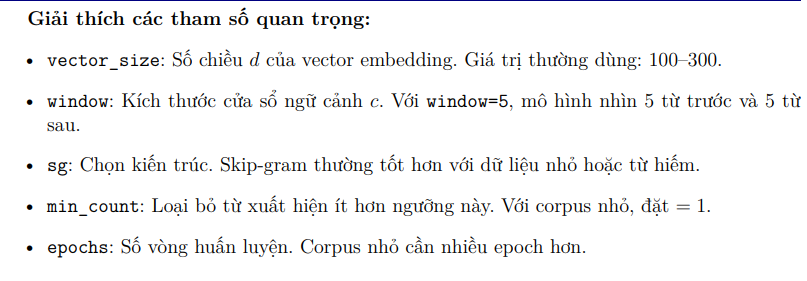

4.3 Khám phá quan hệ ngữ nghĩa


In [ ]:
# Tim cac tu gan nghia nhat
print("=== Cac tu gan nhat voi 'pho' ===")
similar_words = model_sg.wv.most_similar("phở", topn=5)
for word, score in similar_words:
  print(f" {word:20s} cosine = {score:.4f}")
print("\n=== Cac tu gan nhat voi 'bong_da' ===")
similar_words = model_sg.wv.most_similar("bóng_đá", topn=5)
for word, score in similar_words:
  print(f" {word:20s} cosine = {score:.4f}")
print("\n=== Cac tu gan nhat voi 'trí_tuệ' ===")
similar_words = model_sg.wv.most_similar("trí_tuệ", topn=5)
for word, score in similar_words:
  print(f" {word:20s} cosine = {score:.4f}")
print("\n=== Cac tu gan nhat voi 'nhân_tạo' ===")
similar_words = model_sg.wv.most_similar("nhân_tạo", topn=5)
for word, score in similar_words:
  print(f" {word:20s} cosine = {score:.4f}")

4.4 Phép toán vector — “Vua – Nam + Nữ = ?”


In [ ]:
# Phep toan tuong tu (analogy)
# Luu y: voi corpus nho, ket qua co the khong chinh xac
# Day la minh hoa y tuong, khong phai ket qua chuan
try:
    # ha_noi - viet_nam + sài_gòn = ?
    result = model_sg.wv.most_similar(
        positive=["hà_nội", "sài_gòn"],
        negative=["việt_nam"],
        topn=3
    )
    print("hà_nội - việt_nam + sài_gòn = ?")
    for word, score in result:
        print(f" {word}: {score:.4f}")
except KeyError as e:
    print(f"Tu khong co trong tu vung: {e}")
    print("(Corpus qua nho -- can du lieu lon hon)")
print()
# Tinh cosine similarity giua hai tu bat ky
from numpy.linalg import norm
def cosine_sim(w1, w2, model):
    """Tinh cosine similarity giua hai tu."""
    v1 = model.wv[w1]
    v2 = model.wv[w2]
    return np.dot(v1, v2) / (norm(v1) * norm(v2))
# So sanh do tuong dong giua cac cap tu
pairs = [
    ("phở", "bún_chả"), # cung chu de am thuc
    ("phở", "bóng_đá"), # khac chu de
    ("học", "trí_tuệ"), # cung chu de cong nghe
    ("học", "phở"), # khac chu de
]
print("=== Do tuong dong cosine giua cac cap tu ===")
for w1, w2 in pairs:
    try:
        sim = cosine_sim(w1, w2, model_sg)
        print(f" sim('{w1}', '{w2}') = {sim:.4f}")
    except KeyError as e:
        print(f" Tu khong tim thay: {e}")

4.5 Trực quan hóa Word Embedding bằng PCA

In [ ]:
from sklearn.decomposition import PCA
# Chon mot so tu de truc quan hoa
words_to_plot = [
    # Am thuc
"phở", "bún_bò", "cơm_tấm", "ẩm_thực", "món_ăn",
# Cong nghe
"trí_tuệ_nhân_tạo", "học_máy", "mô_hình", "thuật_toán",
# The thao
"bóng_đá", "cầu_thủ", "đội_tuyển", "thể_thao",
# Dia danh
"hà_nội", "việt_nam",
]
# Loc cac tu co trong tu vung
words_available = [w for w in words_to_plot if w in model_sg.wv]
vectors = np.array([model_sg.wv[w] for w in words_available])
print(f"So tu de truc quan hoa: {len(words_available)}")
print(f"Kich thuoc ma tran vector: {vectors.shape}")
# Giam chieu tu 100 xuong 2 bang PCA
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)
print(f"Phuong sai giai thich: {pca.explained_variance_ratio_.sum():.2%}")

In [ ]:
# Ve bieu do
fig, ax = plt.subplots(figsize=(12, 8))
# Mau sac theo chu de
colors = []
for w in words_available:
    if w in ["phở", "bún_bò", "cơm_tấm", "ẩm_thực", "món_ăn"]:
        colors.append('red')
    elif w in ["trí_tuệ_nhân_tạo", "học_máy", "mô_hình", "thuật_toán"]:
        colors.append('blue')
    elif w in ["bóng_đá", "cầu_thủ", "đội_tuyển", "thể_thao"]:
        colors.append('green')
    else:
        colors.append('purple')
ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1],
           c=colors, s=100, alpha=0.7, edgecolors='black')
for i, word in enumerate(words_available):
    ax.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]),
                fontsize=9, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')
ax.set_title("Word2Vec Embedding (PCA 2D) -- Tieng Viet")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.grid(True, alpha=0.3)
# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label='Am thuc'),
    Patch(facecolor='blue', label='Cong nghe'),
    Patch(facecolor='green', label='The thao'),
    Patch(facecolor='purple', label='Dia danh'),
]
ax.legend(handles=legend_elements, loc='best')
plt.tight_layout()
plt.savefig("word2vec_pca.png", dpi=150)
plt.show()

5 GloVe — Sử dụng Embedding Pre-trained   
5.1 Xây dựng ma trận đồng xuất hiện

In [ ]:
from collections import defaultdict
import numpy as np

def build_cooccurrence_matrix(sentences, window=2):
    """
    Xay dung ma tran dong xuat hien tu danh sach cac cau.
    Tham so:
    sentences: list cac list tu
    window: kich thuoc cua so ngu canh
    Tra ve:
    vocab: danh sach tu
    matrix: ma tran dong xuat hien (numpy array)
    """
    # Dem so lan dong xuat hien
    cooccur = defaultdict(lambda: defaultdict(int))
    for sent in sentences:
        for i, word in enumerate(sent):
            # Duyet cac tu trong cua so
            start = max(0, i - window)
            end = min(len(sent), i + window + 1)
            for j in range(start, end):
                if i != j:
                    cooccur[word][sent[j]] += 1

    # Tao tu vung
    vocab = sorted(list(cooccur.keys()))
    word_to_idx = {word: i for i, word in enumerate(vocab)}

    # Tao ma tran dong xuat hien
    matrix = np.zeros((len(vocab), len(vocab)), dtype=int)
    for word1, neighbors in cooccur.items():
        idx1 = word_to_idx[word1]
        for word2, count in neighbors.items():
            if word2 in word_to_idx:
                idx2 = word_to_idx[word2]
                matrix[idx1][idx2] = count

    return vocab, matrix

# Call the function to build the co-occurrence matrix
vocab_co, cooccur_matrix = build_cooccurrence_matrix(sentences_for_w2v, window=2)

5.2 Trực quan hóa ma trận đồng xuất hiện

In [ ]:
# Chon mot so tu de xem chi tiet
selected_words = ["phở", "hà_nội", "bóng_đá", "học_máy",
"việt_nam", "cầu_thủ", "nước_dùng"]
selected_words = [w for w in selected_words if w in vocab_co]
# Lay chi so
indices = [vocab_co.index(w) for w in selected_words]
# Trich ma tran con
sub_matrix = cooccur_matrix[np.ix_(indices, indices)]
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(sub_matrix, cmap='Blues')
ax.set_xticks(range(len(selected_words)))
ax.set_yticks(range(len(selected_words)))
ax.set_xticklabels(selected_words, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(selected_words, fontsize=9)
for i in range(len(selected_words)):
  for j in range(len(selected_words)):
    ax.text(j, i, f"{int(sub_matrix[i,j])}",
      ha="center", va="center", fontsize=10,
      color="white" if sub_matrix[i,j] > sub_matrix.max()/2
      else "black")
plt.colorbar(im, ax=ax, label='So lan dong xuat hien')
plt.title("Ma tran dong xuat hien (Co-occurrence Matrix)")
plt.tight_layout()
plt.savefig("cooccurrence.png", dpi=150)
plt.show()


5.3 So sánh trực tiếp Word2Vec vs GloVe

In [ ]:
# ====================================================
# CACH 1: Dung gensim de tai GloVe pre-trained
# (file nay la GloVe tieng Anh de minh hoa)
# ====================================================
import gensim.downloader as api
# Tai mo hinh GloVe nho (50 chieu) -- tieng Anh
# (De minh hoa cach su dung, vi GloVe tieng Viet
# khong co san tren gensim)
print("Dang tai GloVe (glove-wiki-gigaword-50)...")
print("(Qua trinh nay mat vai phut)")
glove_model = api.load("glove-wiki-gigaword-50")
print(f"So tu: {len(glove_model)}")
print(f"So chieu: {glove_model.vector_size}")
# Kiem tra voi tieng Anh
print("\nTu gan voi 'king':")
for word, score in glove_model.most_similar("king", topn=5):
  print(f" {word}: {score:.4f}")
# Phep toan: king - man + woman = ?
result = glove_model.most_similar(
positive=["king", "woman"],
negative=["man"],
topn=3
)
print("\nking - man + woman = ?")
for word, score in result:
  print(f" {word}: {score:.4f}")

In [ ]:
# ====================================================
# CACH 2: Su dung GloVe cho tieng Viet
# Bang cach tai PhoW2V (Word2Vec format) hoac
# su dung embedding tu ETNLP
# ====================================================
# Vi du voi PhoW2V (neu da tai ve):
# from gensim.models import KeyedVectors
# phow2v = KeyedVectors.load_word2vec_format(
    # 'PhoW2V_syllables.bin', binary=True
# )
# print(phow2v.most_similar("hà_nội", topn=5))
# Trong bai thuc hanh nay, chung ta su dung mo hinh
# Word2Vec da huan luyen o Section 4 de so sanh
print("=== So sanh Skip-gram va CBOW ===")
test_words = ["phở", "bóng_đá", "trí_tuệ_nhân_tạo"]
for word in test_words:
  if word in model_sg.wv and word in model_cbow.wv:
    sim_sg = model_sg.wv.most_similar(word, topn=3)
    sim_cbow = model_cbow.wv.most_similar(word, topn=3)
    print(f"\nTu: '{word}'")
    print(f" Skip-gram: {[w for w, s in sim_sg]}")
    print(f" CBOW: {[w for w, s in sim_cbow]}")

6 Hạn chế: Static Embedding không hiểu ngữ cảnh  
6.1 Thí nghiệm 1: Từ “đường” trong các ngữ cảnh khác nhau


In [ ]:
# Cac cau chua tu "duong" voi nghia khac nhau
sentences_duong = {
"duong_di": [
"Tôi đi trên đường Nguyễn Huệ rất đẹp.",
"Con đường từ nhà đến trường rất xa.",
"Đường phố Hà Nội đông đúc vào giờ cao điểm.",
],
"duong_an": [
"Cho thêm đường vào cà phê cho ngọt.",
"Đường cát trắng dùng để làm bánh.",
"Bệnh tiểu đường liên quan đến lượng đường trong máu.",
],
"duong_ke": [
"Vẽ một đường thẳng trên giấy.",
"Đường cong này biểu diễn hàm số bậc hai.",
"Hai đường song song không bao giờ cắt nhau.",
],
}
# Voi Word2Vec: tu "duong" chi co 1 vector duy nhat
# Tach tu va kiem tra
for context, sents in sentences_duong.items():
  print(f"\n--- Ngu canh: {context} ---")
  for sent in sents:
    tokens = word_tokenize(sent, format="text").lower().split()
    print(f" Tokens: {tokens}")
    # Tim vi tri cua tu "duong"
    if "đường" in tokens:
      print(f" -> Tu 'duong' xuat hien tai vi tri "
        f"{tokens.index('đường')}")


In [ ]:
# Chung minh: Word2Vec tra ve CUNG MOT vector cho "duong"
# bat ke ngu canh
# Huan luyen Word2Vec tren cac cau co tu "duong"
all_duong_sents = []
for sents in sentences_duong.values():
  for sent in sents:
    tokens = word_tokenize(sent, format="text").lower().split()
    all_duong_sents.append(tokens)
# Them ca corpus cu
all_sents = sentences_for_w2v + all_duong_sents
model_duong = Word2Vec(
sentences=all_sents,
vector_size=100, window=5, min_count=1,
sg=1, epochs=100, seed=42
)
# Lay vector cua "duong"
if "đường" in model_duong.wv:
  vec_duong = model_duong.wv["đường"]
  print(f"Vector cua 'duong' (5 chieu dau): {vec_duong[:5]}")
  print(f"Day la vector DUY NHAT cho tu 'duong'!")
  print(f"Du no xuat hien voi 3 nghia hoan toan khac nhau.")
  print()
  # Tim cac tu gan nhat
  similar = model_duong.wv.most_similar("đường", topn=10)
  print("Cac tu gan nhat voi 'duong':")
  for word, score in similar:
    print(f" {word:20s} {score:.4f}")
  print()
  print("=> Cac tu gan voi 'duong' la HON HOP cua ca 3 nghia!")
  print(" Mo hinh KHONG BIET 'duong' nao dang duoc noi den.")

6.2 Thí nghiệm 2: Phủ định không thay đổi embedding

In [ ]:
# Minh hoa: phu dinh khong thay doi vector tu
# "hay" trong "Phim nay hay" va "Phim nay KHONG hay"
sent_positive = "phim này hay"
sent_negative = "phim này không hay"
tokens_pos = word_tokenize(sent_positive, format="text").lower().split()
tokens_neg = word_tokenize(sent_negative, format="text").lower().split()
print(f"Cau tich cuc: {tokens_pos}")
print(f"Cau tieu cuc: {tokens_neg}")
print()
# Trong Word2Vec, vector cua "hay" la giong nhau
# trong ca hai cau
if "hay" in model_duong.wv:
  vec_hay = model_duong.wv["hay"]
  print(f"Vector 'hay' trong cau tich cuc: {vec_hay[:3]}...")
  print(f"Vector 'hay' trong cau tieu cuc: {vec_hay[:3]}...")
  print(f"GIONG NHAU 100%!")
  print()
  print("=> Static embedding KHONG phan biet duoc")
  print(" cam xuc tich cuc va tieu cuc!")


7 Contextual Embedding với PhoBERT   
7.1 Nạp mô hình PhoBERT

In [ ]:
from transformers import AutoModel, AutoTokenizer
import torch
# Nap PhoBERT (base, nho hon, phu hop voi Google Colab)
print("Dang tai PhoBERT-base... (lan dau mat vai phut)")
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
model = AutoModel.from_pretrained("vinai/phobert-base")
# Chuyen sang evaluation mode (khong can gradient)
model.eval()
print(f"Mo hinh: vinai/phobert-base")
print(f"So lop Transformer: {model.config.num_hidden_layers}")
print(f"So chieu embedding: {model.config.hidden_size}")
print(f"So luong tham so: ~110M")

7.2 Cách PhoBERT tokenize tiếng Việt

In [ ]:
# PhoBERT yeu cau: dau vao phai duoc TACH TU truoc
# (dung VnCoreNLP hoac Underthesea)
from underthesea import word_tokenize
sentence = "Hà Nội là thủ đô của Việt Nam"
# Buoc 1: Tach tu tieng Viet
segmented = word_tokenize(sentence, format="text")
print(f"Sau khi tach tu: {segmented}")
# Buoc 2: PhoBERT tokenize (BPE - Byte Pair Encoding)
encoded = tokenizer(segmented, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'][0])
print(f"PhoBERT tokens: {tokens}")
print(f"Token IDs: {encoded['input_ids'][0].tolist()}")
print()
print("Giai thich:")
print(" <s> = token bat dau cau (tuong tu [CLS] trong BERT)")
print(" </s> = token ket thuc cau (tuong tu [SEP] trong BERT)")
print(" @@ = subword (BPE chia tu thanh cac phan nho hon)")


7.3 Tạo Contextual Embedding

In [ ]:
def get_contextual_embeddings(sentence, tokenizer, model):
    """
    Tao contextual embedding cho mot cau tieng Viet.
    Buoc thuc hien:
    1. Tach tu tieng Viet (underthesea)
    2. Tokenize bang PhoBERT tokenizer (BPE)
    3. Cho qua mo hinh PhoBERT
    4. Lay embedding tu lop cuoi cung
    Tra ve:
    tokens: danh sach cac token
    embeddings: ma tran embedding (num_tokens x 768)
    """
    # Buoc 1: Tach tu
    segmented = word_tokenize(sentence, format="text")
    # Buoc 2: Tokenize
    encoded = tokenizer(
        segmented,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=256
    )
    # Buoc 3: Forward pass (khong tinh gradient)
    with torch.no_grad():
        outputs = model(**encoded)
    # Buoc 4: Lay hidden states tu lop cuoi cung
    # outputs.last_hidden_state co kich thuoc:
    # (batch_size, sequence_length, hidden_size)
    embeddings = outputs.last_hidden_state[0] # bo chieu batch
    # Lay danh sach token
    tokens = tokenizer.convert_ids_to_tokens(
        encoded['input_ids'][0]
    )
    return tokens, embeddings.numpy()
# Thu nghiem
tokens, embeddings = get_contextual_embeddings(
    "Hà Nội là thủ đô của Việt Nam",
    tokenizer, model
)
print("Token | Kich thuoc embedding")
print("-" * 40)
for tok, emb in zip(tokens, embeddings):
    print(f"{tok:14s} | {emb.shape}")

7.4 Thí nghiệm quyết định: “đường” trong các ngữ cảnh


In [ ]:
# Ba cau voi tu "duong" mang nghia khac nhau
sentences_test = [
"Tôi đi trên đường Nguyễn Huệ rất đẹp", # duong di
"Cho thêm đường vào cà phê cho ngọt", # duong an
"Vẽ một đường thẳng trên giấy", # duong ke
]
labels = ["duong = road", "duong = sugar", "duong = line"]
# Lay embedding cua tu "duong" trong moi cau
duong_embeddings = []
for sent, label in zip(sentences_test, labels):
    tokens, embeddings = get_contextual_embeddings(
        sent, tokenizer, model
    )
    # Tim vi tri cua token "đường" (hoac subword chua "duong")
    for i, tok in enumerate(tokens):
        if "đường" in tok.lower().replace("_", " "):
            duong_embeddings.append({
                'label': label,
                'sentence': sent,
                'token': tok,
                'embedding': embeddings[i],
                'position': i
            })
            print(f"[{label}]")
            print(f" Cau: {sent}")
            print(f" Token: '{tok}' tai vi tri {i}")
            print(f" Embedding (3 chieu dau): "
                  f"{embeddings[i][:3]}")
            print()
            break
# Tinh cosine similarity giua cac embedding cua "duong"
print("=" * 50)
print("COSINE SIMILARITY GIUA CAC EMBEDDING CUA 'DUONG'")
print("=" * 50)
for i in range(len(duong_embeddings)):
    for j in range(i+1, len(duong_embeddings)):
        v1 = duong_embeddings[i]['embedding']
        v2 = duong_embeddings[j]['embedding']
        sim = np.dot(v1, v2) / (
            np.linalg.norm(v1) * np.linalg.norm(v2)
        )
        print(f" sim({duong_embeddings[i]['label']}, "
              f"{duong_embeddings[j]['label']}) = {sim:.4f}")

7.5 So sánh trực quan: Static vs Contextual

In [ ]:
# ====================================================
# So sanh tong hop: Word2Vec (static) vs PhoBERT (contextual)
# voi nhieu tu da nghia tieng Viet
# ====================================================
ambiguous_tests = {
    "chạy": [
        ("Em bé chạy ngoài sân", "di chuyen"),
        ("Máy tính chạy chương trình", "thuc thi"),
        ("Đồng hồ đang chạy", "hoat dong"),
    ],
    "sao": [
        ("Bầu trời đầy sao sáng", "ngoi sao"),
        ("Sao em không đi học", "tai sao"),
        ("Anh ấy sao chép bài", "sao chep"),
    ],
}
for word, test_cases in ambiguous_tests.items():
    print(f"\n{'='*60}")
    print(f"TU DA NGHIA: '{word}'")
    print(f"{'='*60}")
    # Lay contextual embedding
    ctx_embeddings = []
    for sent, meaning in test_cases:
        tokens, embeddings = get_contextual_embeddings(
            sent, tokenizer, model
        )
        # Tim token chua tu can tim
        for i, tok in enumerate(tokens):
            if word in tok.lower().replace("_", " "):
                ctx_embeddings.append(embeddings[i])
                print(f"\n [{meaning}] '{sent}'")
                print(f" Token: '{tok}', vi tri: {i}")
                print(f" Embedding (3 chieu dau): "
                      f"{embeddings[i][:3]}")
                print()
                break
    # Tinh cosine similarity
    if len(ctx_embeddings) >= 2:
        print(f"\n Cosine similarity (PhoBERT - contextual):")
        for i in range(len(ctx_embeddings)):
            for j in range(i+1, len(ctx_embeddings)):
                v1, v2 = ctx_embeddings[i], ctx_embeddings[j]
                sim = np.dot(v1, v2) / (
                    np.linalg.norm(v1) * np.linalg.norm(v2)
                )
                print(f" sim({test_cases[i][1]}, "
                      f"{test_cases[j][1]}) = {sim:.4f}")
        print(f"\n Trong khi do, Word2Vec (static):")
        print(f" sim = 1.0000 (vi chi co 1 vector duy nhat)")

7.6 Thí nghiệm phủ định: “hay” vs “không hay”

In [ ]:
# Kiem tra: PhoBERT co phan biet "hay" va "khong hay"?
sent_pos = "Bộ phim này rất hay và cảm động"
sent_neg = "Bộ phim này không hay chút nào"
# Lay embedding
tokens_pos, emb_pos = get_contextual_embeddings(
sent_pos, tokenizer, model
)
tokens_neg, emb_neg = get_contextual_embeddings(
sent_neg, tokenizer, model
)
# Tim vi tri cua "hay"
idx_pos = next(i for i, t in enumerate(tokens_pos) if "hay" in t)
idx_neg = next(i for i, t in enumerate(tokens_neg) if "hay" in t)
vec_hay_pos = emb_pos[idx_pos]
vec_hay_neg = emb_neg[idx_neg]
# Tinh cosine similarity
sim = np.dot(vec_hay_pos, vec_hay_neg) / (
np.linalg.norm(vec_hay_pos) * np.linalg.norm(vec_hay_neg)
)
print(f"Cau tich cuc: '{sent_pos}'")
print(f" Token 'hay' tai vi tri {idx_pos}")
print()
print(f"Cau tieu cuc: '{sent_neg}'")
print(f" Token 'hay' tai vi tri {idx_neg}")
print()
print(f"Cosine similarity (PhoBERT): {sim:.4f}")
print(f"Cosine similarity (Word2Vec): 1.0000")
print()
if sim < 0.95:
  print("=> PhoBERT PHAN BIET DUOC ngu canh tich cuc/tieu cuc!")
  print(" Vector 'hay' KHAC NHAU trong 2 cau.")
else:
  print("=> Vector kha giong nhau, nhung van khac (khong = 1.0)")

7.7 Trực quan hóa tổng hợp: Static vs Contextual


In [ ]:
from sklearn.decomposition import PCA
# Thu thap tat ca embedding cua "duong" tu nhieu cau
all_sentences = [
# Nghia 1: duong di
"Tôi đi trên đường Nguyễn Huệ",
"Con đường từ nhà đến trường rất xa",
"Đường phố đông đúc vào giờ cao điểm",
"Đường cao tốc giúp di chuyển nhanh hơn",
# Nghia 2: duong an
"Cho thêm đường vào cà phê",
"Đường cát trắng dùng để làm bánh",
"Ăn nhiều đường không tốt cho sức khỏe",
"Nhà máy sản xuất đường từ mía",
# Nghia 3: duong ke
"Vẽ một đường thẳng trên giấy",
"Đường cong biểu diễn hàm số",
"Hai đường song song không cắt nhau",
"Đường tròn có bán kính năm centimet",
]
sense_labels = (["road"]*4 + ["sugar"]*4 + ["line"]*4)
sense_colors = (["red"]*4 + ["blue"]*4 + ["green"]*4)
# Lay embedding cua "duong" tu PhoBERT
ctx_vecs = []
for sent in all_sentences:
  tokens, embs = get_contextual_embeddings(
sent, tokenizer, model
)
  for i, tok in enumerate(tokens):
    if "đường" in tok.lower().replace("_", " "):
      ctx_vecs.append(embs[i])
      break
ctx_vecs = np.array(ctx_vecs)
print(f"So embedding thu thap: {ctx_vecs.shape[0]}")
# PCA giam chieu xuong 2D
pca = PCA(n_components=2)
ctx_2d = pca.fit_transform(ctx_vecs)
# Ve bieu do
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# --- Panel trai: Static Embedding ---
ax1 = axes[0]
# Tat ca deu la cung 1 diem (vi chi co 1 vector)
ax1.scatter([0], [0], c='black', s=200, marker='X',
zorder=5, label="duong (tat ca nghia)")
ax1.set_xlim(-1, 1)
ax1.set_ylim(-1, 1)
ax1.set_title("Static Embedding (Word2Vec/GloVe)\n"
"Tu 'duong' chi co 1 diem duy nhat",
fontsize=11)
ax1.set_xlabel("Chieu 1")
ax1.set_ylabel("Chieu 2")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.text(0.05, -0.3, "1 vector cho\nTAT CA nghia",
fontsize=10, ha='center',
bbox=dict(boxstyle='round', facecolor='wheat'))
# --- Panel phai: Contextual Embedding ---
ax2 = axes[1]
for i, (x, y) in enumerate(ctx_2d):
  ax2.scatter(x, y, c=sense_colors[i], s=80, alpha=0.8,
edgecolors='black', linewidth=0.5)
# Legend
from matplotlib.patches import Patch
legend_elements = [
Patch(facecolor='red', label='duong = road'),
Patch(facecolor='blue', label='duong = sugar'),
Patch(facecolor='green', label='duong = line'),
]
ax2.legend(handles=legend_elements, loc='best')
ax2.set_title("Contextual Embedding (PhoBERT)\n"
"Tu 'duong' co NHIEU diem khac nhau",
fontsize=11)
ax2.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax2.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("static_vs_contextual.png", dpi=150,
            bbox_inches='tight')
plt.show()
print("\nKet luan: PhoBERT tao ra cac CUM RIENG BIET")
print("cho moi nghia cua tu 'duong'!")

8 Tổng kết và Bài tập nâng cao   
8.1 Bảng so sánh tổng hợp

In [ ]:
# In bang so sanh tong hop
print("""
+---------------------+--------+---------------+------------------+
| Tinh chat | BoW | Word2Vec/GloVe| PhoBERT |
+---------------------+--------+---------------+------------------+
| Vector day dac | Khong | Co | Co |
| Nam bat ngu nghia | Khong | Co | Co |
| Hieu ngu canh | Khong | Khong | Co |
| Xu ly da nghia | Khong | Khong | Co |
| Hieu phu dinh | Khong | Khong | Co (1 phan) |
| So chieu | |V| | 100-300 | 768 |
| Toc do tinh toan | Nhanh | Nhanh | Cham |
| Can GPU | Khong | Khong | Nen co |
| Pre-trained Viet | N/A | PhoW2V, | PhoBERT |
| | | word2vecVN | ViDeBERTa |
+---------------------+--------+---------------+------------------+
""")
